# Plots of deterministic results

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp
import scipy.special as sps

## Rate constants

In [2]:
R = 0.00888
K = 0.00772

## $\frac{F_{fast}}{A}$ plot vs. $\frac{N}{A}$

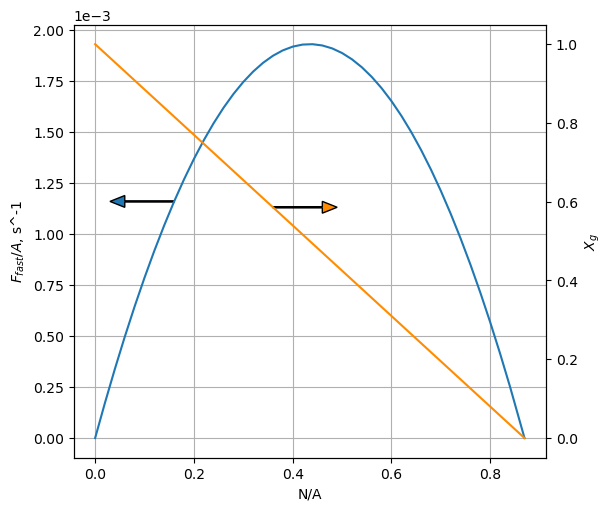

In [19]:
density = np.arange(0, K/R, 0.02)
density[-1] = K/R

T = np.arange(0, 3601, 50)
T[0] = 1 #can't have T=0 because that will result in division by 0

F_fastA = density*R - density**2 * R**2 / K
X_g = 1-density*R/K

for i in range(0, F_fastA.size):
    if F_fastA[i] < 0:
        F_fastA[i]=0

f, ax = plt.subplots(layout="constrained", figsize=(6,5))

ax.plot(density, F_fastA)

ax.set_xlabel("N/A")
ax.set_ylabel("$F_{fast}/A$, s^-1")
ax.grid(True)

ax.ticklabel_format(scilimits=(-2,5))

ax.arrow(density[8], F_fastA[8], -0.1, 0,
         width=0.003*(F_fastA.max()-F_fastA.min()),
         head_width=0.03*(F_fastA.max()-F_fastA.min()),
         head_length=0.03)

ax2 = ax.twinx()

ax2.plot(density, X_g, "darkorange")
ax2.set_ylabel("$X_g$")

ax2.arrow(density[18], X_g[18], 0.1, 0,
         width=0.003*(X_g.max()-X_g.min()),
         head_width=0.03*(X_g.max()-X_g.min()),
         head_length=0.03,
         facecolor="darkorange")

#plt.show()
plt.savefig("f_fast.png")

## $\frac{F_{slow}}{A}$ plot vs. $\frac{N}{A}$ and $T$

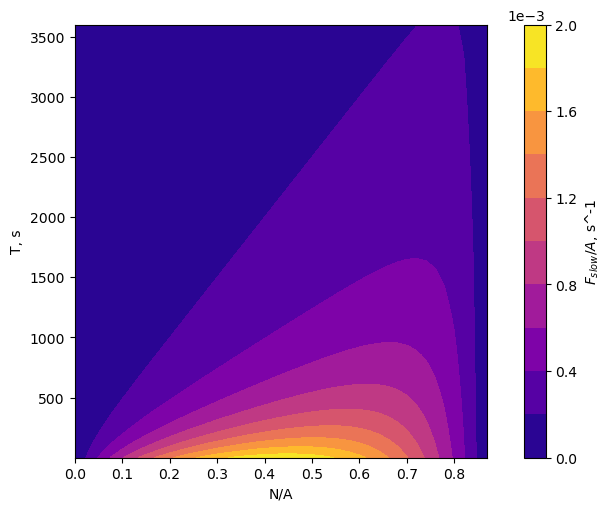

In [4]:
dd, TT = np.meshgrid(density, T)

F_slowA = dd*(1 - np.exp(-TT*R + TT*R**2*dd/K))/TT

f, ax = plt.subplots(layout="constrained", figsize=(6,5))

im_ptr = ax.contourf(dd, TT, F_slowA, levels=10, cmap="plasma")

cb = plt.colorbar(im_ptr, ax=ax, label="$F_{slow}/A$, s^-1")
cb.formatter.set_powerlimits((-1, 5))

ax.set_xlabel("N/A")
ax.set_ylabel("T, s")

#plt.show()
plt.savefig("f_slow_contour.png")

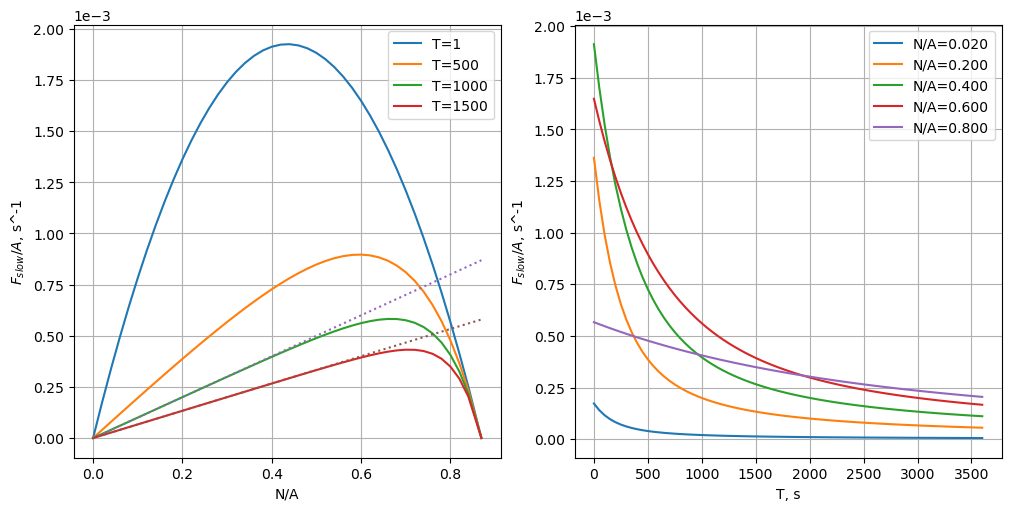

In [5]:
f, axs = plt.subplots(nrows=1, ncols=2, layout="constrained", figsize=(10,5))

axs[0].plot(density, F_slowA[0,0:], "-", label="T={0:.0f}".format(T[0]))
axs[0].plot(density, F_slowA[10,0:], "-", label="T={0:.0f}".format(T[10]))
axs[0].plot(density, F_slowA[20,0:], "-", label="T={0:.0f}".format(T[20]))
axs[0].plot(density, F_slowA[30,0:], "-", label="T={0:.0f}".format(T[30]))

axs[0].plot(density, density/1000, ":")
axs[0].plot(density, density/1500, ":")

axs[0].set_xlabel("N/A")
axs[0].set_ylabel("$F_{slow}/A$, s^-1")

axs[1].plot(T, F_slowA[0:,1], "-", label="N/A={0:.3f}".format(density[1]))
axs[1].plot(T, F_slowA[0:,10], "-", label="N/A={0:.3f}".format(density[10]))
axs[1].plot(T, F_slowA[0:,20], "-", label="N/A={0:.3f}".format(density[20]))
axs[1].plot(T, F_slowA[0:,30], "-", label="N/A={0:.3f}".format(density[30]))
axs[1].plot(T, F_slowA[0:,40], "-", label="N/A={0:.3f}".format(density[40]))

axs[1].set_xlabel("T, s")
axs[1].set_ylabel("$F_{slow}/A$, s^-1")

axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)

axs[0].ticklabel_format(scilimits=(-2,5))
axs[1].ticklabel_format(scilimits=(-2,5))

#plt.show()
plt.savefig("f_slow_na_t.png")

## Optimal sheep density vs T for slow farmer

C:\Users\evanf\anaconda3\envs\general_sci\Lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


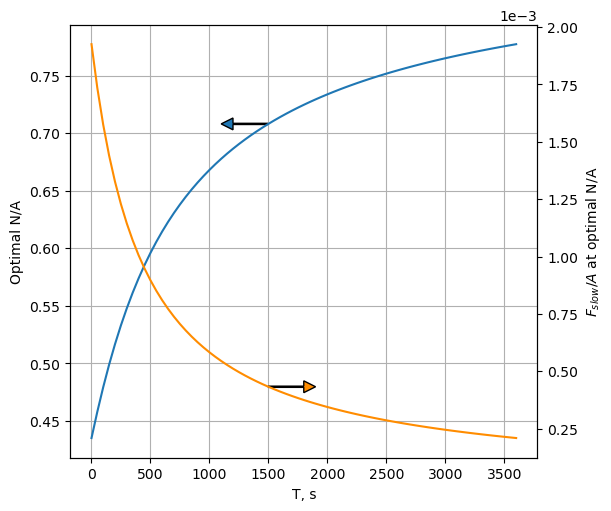

In [6]:
f, ax = plt.subplots(layout="constrained", figsize=(6,5))

N_opt = K*(sps.lambertw(np.exp(T*R+1))-1)/(T*R**2)
ax.plot(T, N_opt,"-")

ax.set_xlabel("T, s")
ax.set_ylabel("Optimal N/A")
ax.grid(True)
ax.arrow(T[30], N_opt[30], -300, 0,
         width=0.003*(N_opt.max()-N_opt.min()),
         head_width=0.03*(N_opt.max()-N_opt.min()),
         head_length=100)

ax2=ax.twinx()

F_slowA = K*(sps.lambertw(np.exp(T*R+1))-1)*(1-np.exp(-T*R+sps.lambertw(np.exp(T*R+1))-1))/(R**2*T**2)
ax2.plot(T, F_slowA, "darkorange") #darkorange is the default second plot color

ax2.set_ylabel("$F_{slow}/A$ at optimal N/A")
ax2.ticklabel_format(scilimits=(-1,5))
ax2.arrow(T[30], F_slowA[30], 300, 0,
          width=0.003*(F_slowA.max()-F_slowA.min()),
          head_width=0.03*(F_slowA.max()-F_slowA.min()),
          head_length=100,
          facecolor="darkorange")

#plt.show()
plt.savefig("optimal_na.png")